In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Clean_Dataset.csv')
print(df.head())

   Unnamed: 0   airline   flight source_city departure_time stops  \
0           0  SpiceJet  SG-8709       Delhi        Evening  zero   
1           1  SpiceJet  SG-8157       Delhi  Early_Morning  zero   
2           2   AirAsia   I5-764       Delhi  Early_Morning  zero   
3           3   Vistara   UK-995       Delhi        Morning  zero   
4           4   Vistara   UK-963       Delhi        Morning  zero   

    arrival_time destination_city    class  duration  days_left  price  
0          Night           Mumbai  Economy      2.17          1   5953  
1        Morning           Mumbai  Economy      2.33          1   5953  
2  Early_Morning           Mumbai  Economy      2.17          1   5956  
3      Afternoon           Mumbai  Economy      2.25          1   5955  
4        Morning           Mumbai  Economy      2.33          1   5955  


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [4]:
# Borramos las columnas que no aportan valor
df = df.drop(['Unnamed: 0'], axis=1)

In [5]:
# Borramos las columnas que no aportan valor 
# Unnamed: 0 es un índice y flight tiene demasiados valores únicos
# df = df.drop(['Unnamed: 0', 'flight'], axis=1)

In [6]:
df.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


In [7]:
# Calculate the correlation matrix using only numeric columns
df_numeric = df.select_dtypes(include=['number'])
df_numeric.corr().T

,duration,days_left,price
duration,1.000000,-0.039157,0.204222
days_left,-0.039157,1.000000,-0.091949
price,0.204222,-0.091949,1.000000


In [8]:
df1=df.groupby(['flight','airline'],as_index=False).count()
df1.airline.value_counts()

airline
Indigo       704
Air_India    218
GO_FIRST     205
SpiceJet     186
Vistara      133
AirAsia      115
Name: count, dtype: int64

Podemos observar que Indigo es la aerolínea más popular

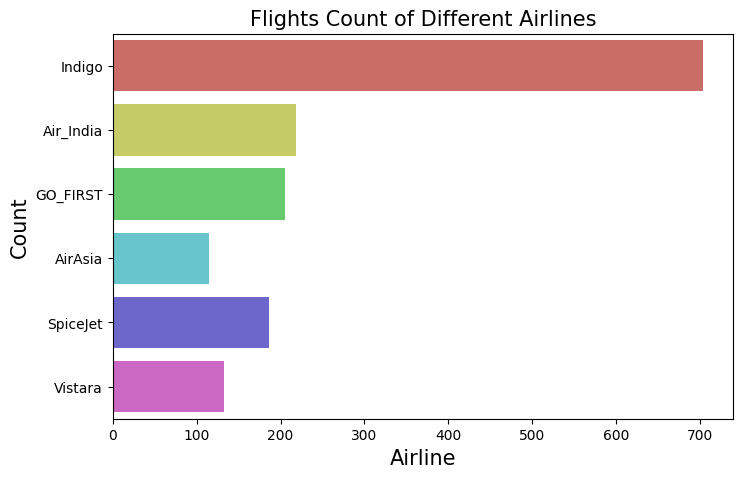

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(df1['airline'],palette='hls')
plt.title('Flights Count of Different Airlines',fontsize=15)
plt.xlabel('Airline',fontsize=15)
plt.ylabel('Count',fontsize=15)
plt.show()

Podemos observar que Economy es la clase más común

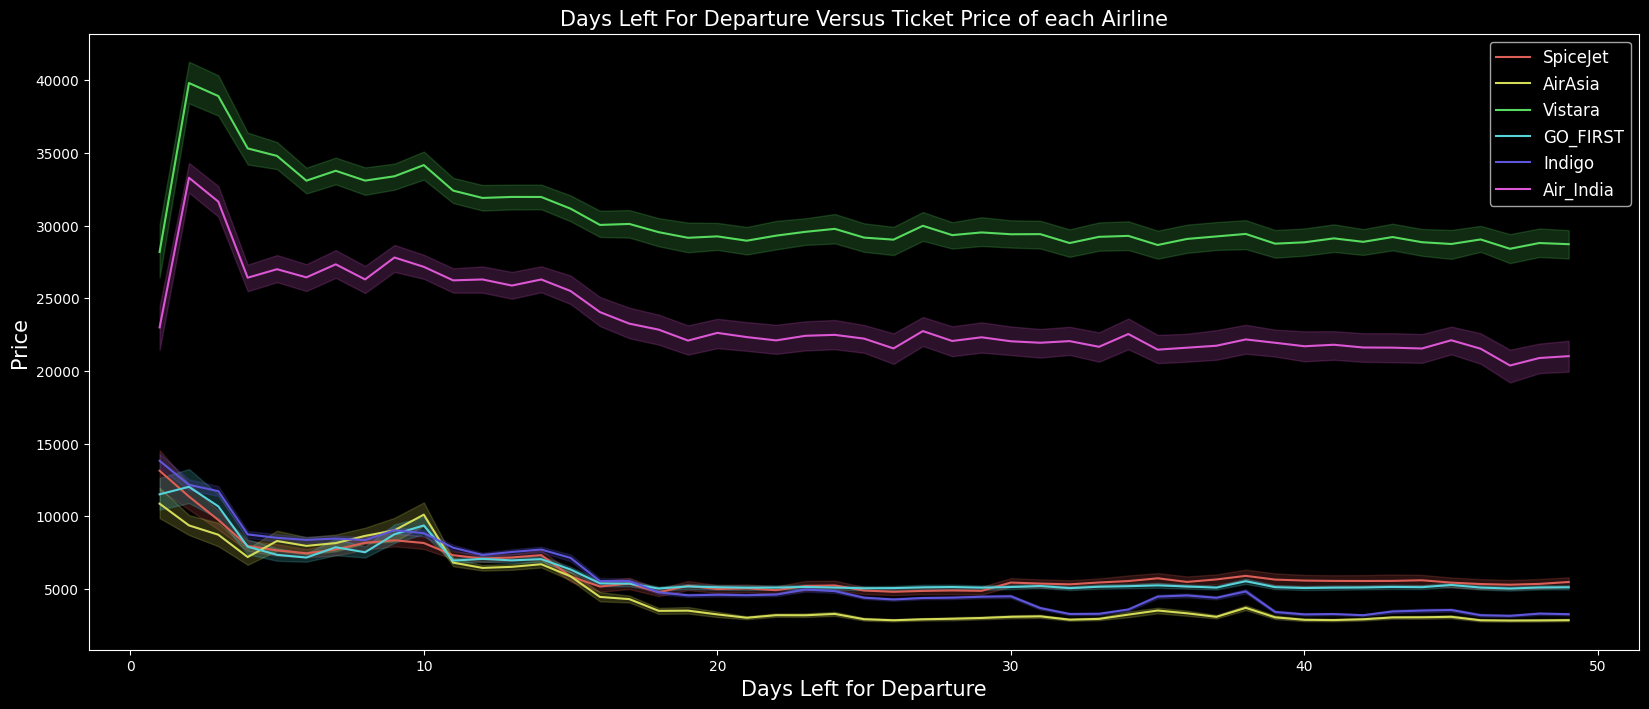

In [18]:
plt.figure(figsize=(20,8))
sns.lineplot(data=df,x='days_left',y='price',color='blue',hue='airline',palette='hls')
plt.title('Days Left For Departure Versus Ticket Price of each Airline',fontsize=15)
plt.legend(fontsize=12)
plt.xlabel('Days Left for Departure',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df_model = df.copy()

group_cols = ['airline', 'source_city', 'destination_city', 'class']
df_model['precio_minimo_futuro'] = df_model.groupby(group_cols)['price'].transform('min')
df_model['bajara_precio'] = (df_model['price'] > df_model['precio_minimo_futuro']).astype(int)

df_model = df_model.drop(['flight', 'price', 'precio_minimo_futuro'], axis=1)

Iniciando Ingeniería de Características...
Ingeniería de Características completada.

Distribución de la variable objetivo:
bajara_precio
1    88.39292
0    11.60708
Name: proportion, dtype: float64

Vista previa de los datos listos para el modelo:
    airline source_city departure_time stops   arrival_time destination_city  \
0  SpiceJet       Delhi        Evening  zero          Night           Mumbai   
1  SpiceJet       Delhi  Early_Morning  zero        Morning           Mumbai   
2   AirAsia       Delhi  Early_Morning  zero  Early_Morning           Mumbai   
3   Vistara       Delhi        Morning  zero      Afternoon           Mumbai   
4   Vistara       Delhi        Morning  zero        Morning           Mumbai   

     class  duration  days_left  bajara_precio  
0  Economy      2.17          1              1  
1  Economy      2.33          1              1  
2  Economy      2.17          1              1  
3  Economy      2.25          1              1  
4  Economy      2.33     

In [21]:
# --- PASO 2: PREPROCESAMIENTO Y PIPELINES (Corregido) ---

# 1. Separar los datos en características (X) y objetivo (y)
X = df_model.drop('bajara_precio', axis=1)
y = df_model['bajara_precio']

# 2. Identificar las columnas numéricas y categóricas
numeric_features = ['duration', 'days_left']
categorical_features = ['airline', 'source_city', 'departure_time', 'arrival_time', 'destination_city', 'class']
ordinal_features = ['stops']

# 3. Definir el orden para las escalas (stops)
stop_categories = ['zero', 'one', 'two_or_more']

# 4. Crear los transformadores para el Pipeline
# Pipeline para variables numéricas
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Pipeline para variables categóricas ordinales (stops)
ordinal_transformer = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(categories=[stop_categories]))
])

# Pipeline para variables categóricas nominales (el resto)
# ----- ESTA ES LA LÍNEA CORREGIDA -----
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
# -------------------------------------

# 5. Combinar los transformadores en un único Preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('ord', ordinal_transformer, ordinal_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 6. Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Datos de entrenamiento: {X_train.shape[0]} muestras")
print(f"Datos de prueba: {X_test.shape[0]} muestras")

Datos de entrenamiento: 240122 muestras
Datos de prueba: 60031 muestras


In [22]:
# --- NIVEL 1: MODELOS LINEALES (Temario T2) ---

# 1. REGRESIÓN LOGÍSTICA (Clasificador Discriminativo)
print("--- Entrenando Regresión Logística ---")
log_reg_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                  ('classifier', LogisticRegression(random_state=42, max_iter=1000))])

# Entrenar el modelo
log_reg_pipeline.fit(X_train, y_train)

# Realizar predicciones
y_pred_log_reg = log_reg_pipeline.predict(X_test)
y_proba_log_reg = log_reg_pipeline.predict_proba(X_test)[:, 1] # Probabilidad de que baje (clase 1)

# Evaluar el modelo
print("Resultados de la Regresión Logística:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log_reg):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_log_reg):.4f}")
print(classification_report(y_test, y_pred_log_reg))
print("-" * 30)

--- Entrenando Regresión Logística ---
Resultados de la Regresión Logística:
Accuracy: 0.8886
ROC-AUC: 0.8509
              precision    recall  f1-score   support

           0       0.56      0.18      0.28      6947
           1       0.90      0.98      0.94     53084

    accuracy                           0.89     60031
   macro avg       0.73      0.58      0.61     60031
weighted avg       0.86      0.89      0.86     60031

------------------------------
Resultados de la Regresión Logística:
Accuracy: 0.8886
ROC-AUC: 0.8509
              precision    recall  f1-score   support

           0       0.56      0.18      0.28      6947
           1       0.90      0.98      0.94     53084

    accuracy                           0.89     60031
   macro avg       0.73      0.58      0.61     60031
weighted avg       0.86      0.89      0.86     60031

------------------------------


In [23]:
# 2. ANÁLISIS DISCRIMINANTE LINEAL (LDA) (Clasificador Generativo)
print("--- Entrenando Análisis Discriminante Lineal (LDA) ---")

# Ahora el preprocesador genera datos densos, por lo que LDA funcionará correctamente.
lda_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', LinearDiscriminantAnalysis(solver='svd'))])

# Entrenar el modelo
lda_pipeline.fit(X_train, y_train)

# Realizar predicciones
y_pred_lda = lda_pipeline.predict(X_test)
y_proba_lda = lda_pipeline.predict_proba(X_test)[:, 1]

# Evaluar el modelo
print("Resultados de LDA:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lda):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lda):.4f}")
print(classification_report(y_test, y_pred_lda))
print("-" * 30)

--- Entrenando Análisis Discriminante Lineal (LDA) ---
Resultados de LDA:
Accuracy: 0.8875
ROC-AUC: 0.8518
              precision    recall  f1-score   support

           0       0.53      0.28      0.37      6947
           1       0.91      0.97      0.94     53084

    accuracy                           0.89     60031
   macro avg       0.72      0.63      0.65     60031
weighted avg       0.87      0.89      0.87     60031

------------------------------
Resultados de LDA:
Accuracy: 0.8875
ROC-AUC: 0.8518
              precision    recall  f1-score   support

           0       0.53      0.28      0.37      6947
           1       0.91      0.97      0.94     53084

    accuracy                           0.89     60031
   macro avg       0.72      0.63      0.65     60031
weighted avg       0.87      0.89      0.87     60031

------------------------------


In [24]:
# --- NIVEL 2: MODELOS NO PARAMÉTRICOS (Temario T5) ---

# Importaciones específicas para estos modelos (si no las has ejecutado)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

# 3. ÁRBOL DE DECISIÓN (DecisionTreeClassifier)
print("--- Entrenando Árbol de Decisión ---")

# Creamos el pipeline
tree_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                ('classifier', DecisionTreeClassifier(random_state=42))])

# --- Validación Cruzada ---
print("Iniciando validación cruzada (CV=3)...")
cv_scores_tree = cross_val_score(tree_pipeline, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1)
print(f"Resultados de Validación Cruzada (ROC-AUC): {cv_scores_tree}")
print(f"ROC-AUC Media (CV): {cv_scores_tree.mean():.4f} (+/- {cv_scores_tree.std():.4f})")
print("-" * 30)

# --- Entrenamiento final y Prueba ---
print("Entrenando modelo de Árbol final en todos los datos de train...")
tree_pipeline.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_tree = tree_pipeline.predict(X_test)
y_proba_tree = tree_pipeline.predict_proba(X_test)[:, 1]

# Evaluar el modelo final
print("\nResultados del Árbol de Decisión en el conjunto de Prueba:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tree):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_tree):.4f}")
print(classification_report(y_test, y_pred_tree))
print("-" * 30)

--- Entrenando Árbol de Decisión ---
Iniciando validación cruzada (CV=3)...
Resultados de Validación Cruzada (ROC-AUC): [0.93827004 0.93831133 0.93658291]
ROC-AUC Media (CV): 0.9377 (+/- 0.0008)
------------------------------
Entrenando modelo de Árbol final en todos los datos de train...
Resultados de Validación Cruzada (ROC-AUC): [0.93827004 0.93831133 0.93658291]
ROC-AUC Media (CV): 0.9377 (+/- 0.0008)
------------------------------
Entrenando modelo de Árbol final en todos los datos de train...

Resultados del Árbol de Decisión en el conjunto de Prueba:
Accuracy: 0.9744
ROC-AUC: 0.9387
              precision    recall  f1-score   support

           0       0.89      0.89      0.89      6947
           1       0.99      0.99      0.99     53084

    accuracy                           0.97     60031
   macro avg       0.94      0.94      0.94     60031
weighted avg       0.97      0.97      0.97     60031

------------------------------

Resultados del Árbol de Decisión en el conju

In [25]:
# --- 4. MODELOS DE ENSAMBLAJE (Temario T5) ---

# a. RANDOM FOREST (BAGGGING)
print("--- Entrenando Random Forest ---")

rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))])

# --- Validación Cruzada ---
print("Iniciando validación cruzada (CV=3)...")
cv_scores_rf = cross_val_score(rf_pipeline, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1)
print(f"Resultados de Validación Cruzada (ROC-AUC): {cv_scores_rf}")
print(f"ROC-AUC Media (CV): {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std():.4f})")
print("-" * 30)

# --- Entrenamiento final y Prueba ---
print("Entrenando modelo Random Forest final en todos los datos de train...")
rf_pipeline.fit(X_train, y_train)

# Realizar predicciones
y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

# Evaluar el modelo final
print("\nResultados del Random Forest en el conjunto de Prueba:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")
print(classification_report(y_test, y_pred_rf))
print("-" * 30)

--- Entrenando Random Forest ---
Iniciando validación cruzada (CV=3)...
Resultados de Validación Cruzada (ROC-AUC): [0.99257247 0.99243488 0.99292222]
ROC-AUC Media (CV): 0.9926 (+/- 0.0002)
------------------------------
Entrenando modelo Random Forest final en todos los datos de train...
Resultados de Validación Cruzada (ROC-AUC): [0.99257247 0.99243488 0.99292222]
ROC-AUC Media (CV): 0.9926 (+/- 0.0002)
------------------------------
Entrenando modelo Random Forest final en todos los datos de train...

Resultados del Random Forest en el conjunto de Prueba:
Accuracy: 0.9744
ROC-AUC: 0.9926
              precision    recall  f1-score   support

           0       0.89      0.89      0.89      6947
           1       0.99      0.99      0.99     53084

    accuracy                           0.97     60031
   macro avg       0.94      0.94      0.94     60031
weighted avg       0.97      0.97      0.97     60031

------------------------------

Resultados del Random Forest en el conjunt

In [26]:
# b. LIGHTGBM (GRADIENT BOOSTING) - CORREGIDO
print("--- Entrenando LightGBM (Versión Corregida) ---")

# Para que LightGBM maneje categóricas dentro de un pipeline de scikit-learn,
# primero debemos convertirlas a enteros (ej. con OrdinalEncoder).
# Luego, le decimos a LGBM cuáles son esas columnas "categóricas" (basado en sus índices).

# 1. Nuevas listas de columnas
numeric_features = ['duration', 'days_left']

# 'stops' ya es ordinal
ordinal_features = ['stops']
stop_categories = ['zero', 'one', 'two_or_more']

# Estas son las que también codificaremos como ordinales para LGBM
categorical_features_lgbm = ['airline', 'source_city', 'departure_time', 'arrival_time', 'destination_city', 'class']

# 2. Creamos un OrdinalEncoder para las categóricas
# handle_unknown='use_encoded_value', unknown_value=-1 es importante
# por si aparece una categoría nueva en los datos de prueba.
categorical_transformer_lgbm = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
ordinal_transformer_stops = Pipeline(steps=[('ordinal', OrdinalEncoder(categories=[stop_categories]))])


# 3. Preprocesador Específico para LGBM
# Todos los tipos de columnas ahora pasan por un transformador
preprocessor_lgbm = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),           # 2 columnas (índice 0, 1)
        ('ord_stops', ordinal_transformer_stops, ordinal_features), # 1 columna (índice 2)
        ('cat', categorical_transformer_lgbm, categorical_features_lgbm) # 6 columnas (índice 3-8)
    ],
    remainder='drop'
)

# 4. Lista de índices de todas las columnas categóricas (stops + el resto)
# Índices 2 (stops) + 3, 4, 5, 6, 7, 8 (el resto)
# (El número total de columnas que verá el clasificador es 2 num + 1 ord + 6 cat = 9)
categorical_indices_lgbm = [2] + list(range(len(numeric_features) + len(ordinal_features), 
                                            len(numeric_features) + len(ordinal_features) + len(categorical_features_lgbm)))

print(f"Índices de columnas categóricas para LGBM: {categorical_indices_lgbm}")


# 5. Crear el Pipeline de LightGBM
# Ahora pasamos los índices categóricos en el constructor
lgbm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_lgbm),
    ('classifier', LGBMClassifier(random_state=42, n_jobs=-1, 
                                  categorical_feature=categorical_indices_lgbm))
])

# --- Validación Cruzada (Ahora funcionará sin 'fit_params') ---
print("Iniciando validación cruzada (CV=3)...")

cv_scores_lgbm = cross_val_score(lgbm_pipeline, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1)

print(f"Resultados de Validación Cruzada (ROC-AUC): {cv_scores_lgbm}")
print(f"ROC-AUC Media (CV): {cv_scores_lgbm.mean():.4f} (+/- {cv_scores_lgbm.std():.4f})")
print("-" * 30)

# --- Entrenamiento final y Prueba ---
print("Entrenando modelo LightGBM final en todos los datos de train...")

# Ya no necesitamos **fit_params**
lgbm_pipeline.fit(X_train, y_train)

# Realizar predicciones
y_pred_lgbm = lgbm_pipeline.predict(X_test)
y_proba_lgbm = lgbm_pipeline.predict_proba(X_test)[:, 1]

# Evaluar el modelo final
print("\nResultados de LightGBM en el conjunto de Prueba:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lgbm):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lgbm):.4f}")
print(classification_report(y_test, y_pred_lgbm))
print("-" * 30)

--- Entrenando LightGBM (Versión Corregida) ---
Índices de columnas categóricas para LGBM: [2, 3, 4, 5, 6, 7, 8]
Iniciando validación cruzada (CV=3)...
Resultados de Validación Cruzada (ROC-AUC): [0.98367015 0.98392884 0.98397017]
ROC-AUC Media (CV): 0.9839 (+/- 0.0001)
------------------------------
Entrenando modelo LightGBM final en todos los datos de train...
Resultados de Validación Cruzada (ROC-AUC): [0.98367015 0.98392884 0.98397017]
ROC-AUC Media (CV): 0.9839 (+/- 0.0001)
------------------------------
Entrenando modelo LightGBM final en todos los datos de train...
[LightGBM] [Info] Number of positive: 212230, number of negative: 27892
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002694 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 346
[LightGBM] [Info] Number of data points in the train set: 240122, number of used features

In [27]:
# --- Guardamos los resultados de los niveles 1 y 2 ---

# Inicializamos el diccionario de resultados
model_results = {
    'Regresión Logística': {
        'roc_auc': roc_auc_score(y_test, y_proba_log_reg),
        'accuracy': accuracy_score(y_test, y_pred_log_reg)
    },
    'LDA': {
        'roc_auc': roc_auc_score(y_test, y_proba_lda),
        'accuracy': accuracy_score(y_test, y_pred_lda)
    },
    'Árbol de Decisión': {
        'roc_auc': roc_auc_score(y_test, y_proba_tree),
        'accuracy': accuracy_score(y_test, y_pred_tree)
    },
    'Random Forest': {
        'roc_auc': roc_auc_score(y_test, y_proba_rf),
        'accuracy': accuracy_score(y_test, y_pred_rf)
    },
    'LightGBM': {
        'roc_auc': roc_auc_score(y_test, y_proba_lgbm),
        'accuracy': accuracy_score(y_test, y_pred_lgbm)
    }
}

print("Resultados de los modelos anteriores guardados.")

Resultados de los modelos anteriores guardados.


In [28]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
%pip install keras

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
# --- NIVEL 3: REDES NEURONALES (Temario T3 y T4) ---

# Importamos las librerías necesarias para este nivel
from sklearn.neural_network import MLPClassifier
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# 5. REDES NEURONALES 1 (MLPClassifier - Temario T3)
print("--- Entrenando Perceptrón Multicapa (MLP) ---")

# Creamos el pipeline con el preprocesador y el clasificador MLP
mlp_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), # Usamos el preprocesador original con OneHotEncoder
    ('classifier', MLPClassifier(hidden_layer_sizes=(64, 64),
                                 activation='relu',
                                 solver='adam',
                                 max_iter=500,
                                 random_state=42,
                                 early_stopping=True, # Para evitar sobreajuste
                                 n_iter_no_change=10))
])

# --- Validación Cruzada ---
print("Iniciando validación cruzada (CV=3)...")
cv_scores_mlp = cross_val_score(mlp_pipeline, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1)
print(f"Resultados de Validación Cruzada (ROC-AUC): {cv_scores_mlp}")
print(f"ROC-AUC Media (CV): {cv_scores_mlp.mean():.4f} (+/- {cv_scores_mlp.std():.4f})")
print("-" * 30)

# --- Entrenamiento final y Prueba ---
print("Entrenando modelo MLP final en todos los datos de train...")
mlp_pipeline.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_mlp = mlp_pipeline.predict(X_test)
y_proba_mlp = mlp_pipeline.predict_proba(X_test)[:, 1]

# Evaluar el modelo final
print("\nResultados del MLP en el conjunto de Prueba:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_mlp):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_mlp):.4f}")
print(classification_report(y_test, y_pred_mlp))
print("-" * 30)

# Guardamos los resultados
model_results['MLP (Scikit-learn)'] = {
    'roc_auc': roc_auc_score(y_test, y_proba_mlp),
    'accuracy': accuracy_score(y_test, y_pred_mlp)
}

--- Entrenando Perceptrón Multicapa (MLP) ---
Iniciando validación cruzada (CV=3)...
Resultados de Validación Cruzada (ROC-AUC): [0.98781691 0.98807395 0.98720315]
ROC-AUC Media (CV): 0.9877 (+/- 0.0004)
------------------------------
Entrenando modelo MLP final en todos los datos de train...
Resultados de Validación Cruzada (ROC-AUC): [0.98781691 0.98807395 0.98720315]
ROC-AUC Media (CV): 0.9877 (+/- 0.0004)
------------------------------
Entrenando modelo MLP final en todos los datos de train...

Resultados del MLP en el conjunto de Prueba:
Accuracy: 0.9573
ROC-AUC: 0.9870
              precision    recall  f1-score   support

           0       0.83      0.79      0.81      6947
           1       0.97      0.98      0.98     53084

    accuracy                           0.96     60031
   macro avg       0.90      0.89      0.89     60031
weighted avg       0.96      0.96      0.96     60031

------------------------------

Resultados del MLP en el conjunto de Prueba:
Accuracy: 0.95

In [31]:
# --- 6. REDES NEURONALES 2 (DNN con Keras - Temario T4) ---

# Fijamos una semilla para que los resultados de la red neuronal sean reproducibles
tf.random.set_seed(42)

print("--- Preparando datos para Keras ---")

# 1. Aplicar el preprocesamiento manualmente
# Usamos el preprocesador original ('preprocessor') con OneHotEncoder
# que ya estaba ajustado a los datos de entrenamiento
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# 2. Crear un conjunto de validación desde el conjunto de entrenamiento
# Esto es crucial para monitorizar el entrenamiento de la red
# Usamos el 20% de los datos de entrenamiento para validación
X_train_nn, X_val_nn, y_train_nn, y_val_nn = train_test_split(
    X_train_processed, y_train, test_size=0.2, random_state=42
)

print(f"Forma de X_train_nn: {X_train_nn.shape}")
print(f"Forma de X_val_nn: {X_val_nn.shape}")
print(f"Forma de X_test_processed: {X_test_processed.shape}")

--- Preparando datos para Keras ---
Forma de X_train_nn: (192097, 35)
Forma de X_val_nn: (48025, 35)
Forma de X_test_processed: (60031, 35)
Forma de X_train_nn: (192097, 35)
Forma de X_val_nn: (48025, 35)
Forma de X_test_processed: (60031, 35)


In [32]:
# --- 6. (Continuación) Definición y Entrenamiento del Modelo DNN ---

print("\n--- Construyendo y Entrenando la Red Neuronal Profunda (DNN) ---")

# Definimos la arquitectura de la red (más profunda, como en T4)
model_dnn = keras.Sequential([
    # Capa de entrada (shape basada en las columnas preprocesadas)
    layers.Input(shape=(X_train_nn.shape[1],)),
    
    # 1ª Capa Oculta
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3), # Técnica de regularización para evitar sobreajuste
    
    # 2ª Capa Oculta
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    
    # 3ª Capa Oculta (¡Más profunda!)
    layers.Dense(32, activation='relu'),
    
    # Capa de Salida
    # Usamos 'sigmoid' porque es un problema de clasificación binaria (0 o 1) [cite: 1712, 1761]
    layers.Dense(1, activation='sigmoid')
])

# Compilamos el modelo
model_dnn.compile(
    optimizer='adam',
    loss='binary_crossentropy', # Pérdida estándar para clasificación binaria
    metrics=['accuracy', tf.keras.metrics.AUC(name='roc_auc')] # Monitorizamos accuracy y ROC-AUC
)

# Resumen de la arquitectura
model_dnn.summary()

# Callback para parar el entrenamiento si no mejora (EarlyStopping)
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_roc_auc', # Monitorizamos el ROC-AUC en el set de validación
    patience=10,           # Número de épocas sin mejora antes de parar
    mode='max',            # Queremos maximizar el ROC-AUC
    restore_best_weights=True # Nos quedamos con los pesos del mejor modelo
)

# Entrenar el modelo
history = model_dnn.fit(
    X_train_nn,
    y_train_nn,
    epochs=100, # Un número alto, EarlyStopping se encargará de parar
    batch_size=128,
    validation_data=(X_val_nn, y_val_nn),
    callbacks=[early_stopping],
    verbose=1
)


--- Construyendo y Entrenando la Red Neuronal Profunda (DNN) ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,977 (58.50 KB)

 Trainable params: 14,977 (58.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9128 - loss: 0.2027 - roc_auc: 0.9265 - val_accuracy: 0.9332 - val_loss: 0.1509 - val_roc_auc: 0.9622
Epoch 2/100
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9128 - loss: 0.2027 - roc_auc: 0.9265 - val_accuracy: 0.9332 - val_loss: 0.1509 - val_roc_auc: 0.9622
Epoch 2/100
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9328 - loss: 0.1519 - roc_auc: 0.9616 - val_accuracy: 0.9428 - val_loss: 0.1285 - val_roc_auc: 0.9732
Epoch 3/100
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9328 - loss: 0.1519 - roc_auc: 0.9616 - val_accuracy: 0.9428 - val_loss: 0.1285 - val_roc_auc: 0.9732
Epoch 3/100
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9389 - loss: 0.1361 - roc_auc: 0.9698 - val_accuracy: 0.9470 - val_loss: 0.1176 - val_roc_auc: 0.9777
Epoch 4/100
1501/1501 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9389 - loss: 0.1361 - roc_auc: 0.9698 - val_accuracy: 0.9470 - val_loss: 0.1

In [33]:
# --- 6. (Continuación) Evaluación del Modelo DNN ---

print("\n--- Evaluación de la Red Neuronal Profunda (DNN) ---")

# Evaluar el modelo final en el conjunto de prueba
loss_dnn, accuracy_dnn, roc_auc_dnn = model_dnn.evaluate(X_test_processed, y_test, verbose=0)

# Obtener las predicciones de probabilidad
y_proba_dnn = model_dnn.predict(X_test_processed).ravel()
# Convertir probabilidades a clases (0 o 1)
y_pred_dnn = (y_proba_dnn > 0.5).astype(int)

print(f"Resultados de la DNN en el conjunto de Prueba:")
print(f"Accuracy: {accuracy_dnn:.4f}")
print(f"ROC-AUC: {roc_auc_dnn:.4f}")
print(classification_report(y_test, y_pred_dnn))
print("-" * 30)

# Guardamos los resultados
model_results['DNN (Keras)'] = {
    'roc_auc': roc_auc_dnn,
    'accuracy': accuracy_dnn
}

print("Resultados de todos los modelos guardados.")


--- Evaluación de la Red Neuronal Profunda (DNN) ---
1876/1876 ━━━━━━━━━━━━━━━━━━━━ 1s 602us/step
1876/1876 ━━━━━━━━━━━━━━━━━━━━ 1s 602us/step
Resultados de la DNN en el conjunto de Prueba:
Accuracy: 0.9615
ROC-AUC: 0.9890
              precision    recall  f1-score   support

           0       0.83      0.83      0.83      6947
           1       0.98      0.98      0.98     53084

    accuracy                           0.96     60031
   macro avg       0.91      0.91      0.91     60031
weighted avg       0.96      0.96      0.96     60031

------------------------------
Resultados de todos los modelos guardados.
Resultados de la DNN en el conjunto de Prueba:
Accuracy: 0.9615
ROC-AUC: 0.9890
              precision    recall  f1-score   support

           0       0.83      0.83      0.83      6947
           1       0.98      0.98      0.98     53084

    accuracy                           0.96     60031
   macro avg       0.91      0.91      0.91     60031
weighted avg       0.96

--- Tabla Comparativa de Rendimiento de Modelos ---
|                          |   roc_auc |   accuracy |
|:-------------------------|----------:|-----------:|
| Random Forest (T5)       |    0.9926 |     0.9744 |
| DNN (Keras) (T4)         |    0.9890 |     0.9615 |
| MLP (Scikit-learn) (T3)  |    0.9870 |     0.9573 |
| LightGBM (T5)            |    0.9824 |     0.9547 |
| Árbol de Decisión (T5)   |    0.9387 |     0.9744 |
| LDA (T2)                 |    0.8518 |     0.8875 |
| Regresión Logística (T2) |    0.8509 |     0.8886 |


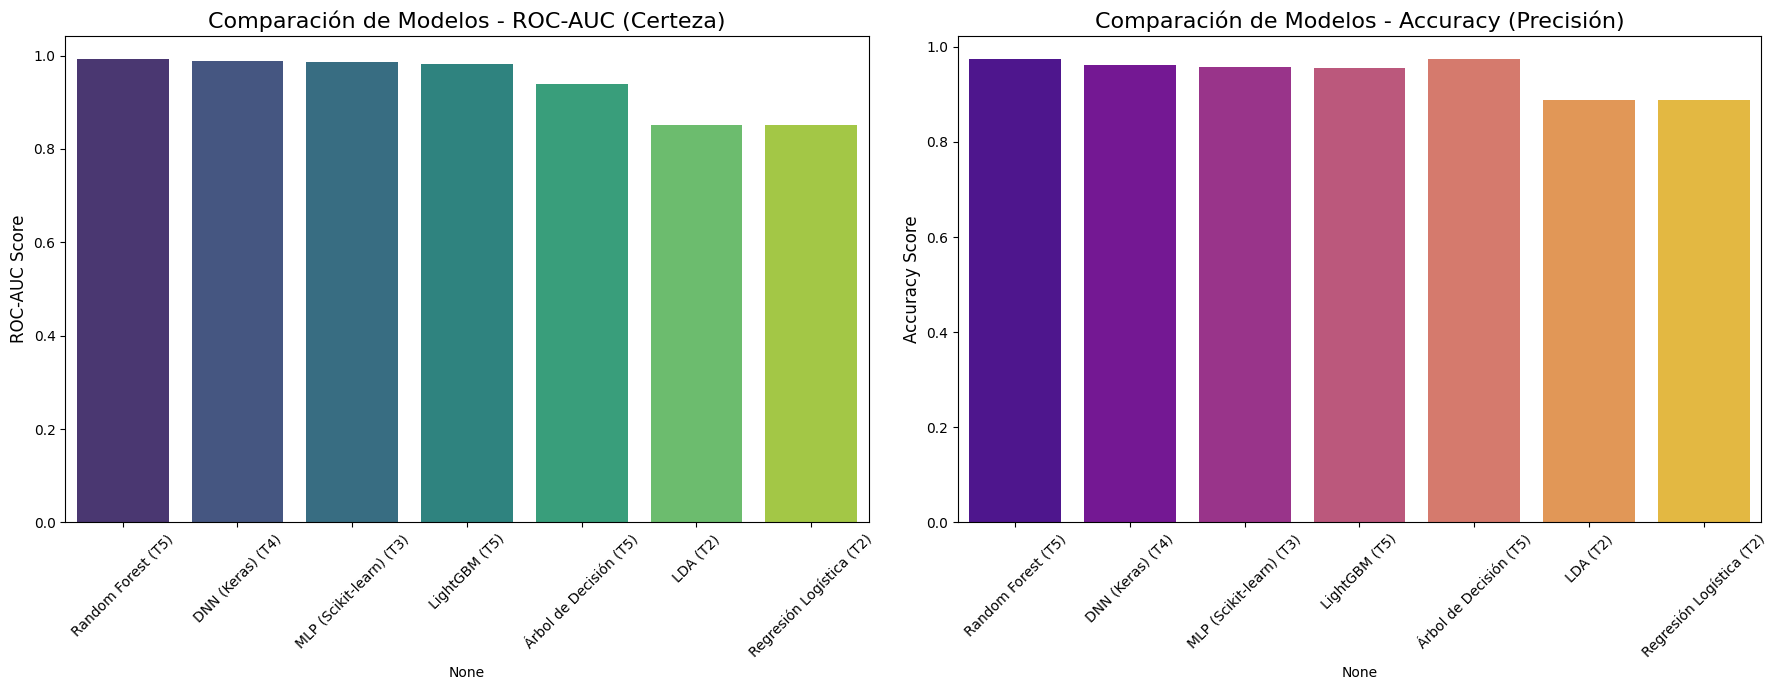

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- RECOPILACIÓN DE TODOS LOS RESULTADOS ---

# (Asegúrate de haber ejecutado las celdas anteriores para que todas las variables 
# como 'roc_auc_log_reg', 'roc_auc_lda', 'accuracy_dnn', etc., estén definidas)

# Re-creamos el diccionario con todos los resultados finales de las pruebas
model_results = {
    'Regresión Logística (T2)': {
        'roc_auc': roc_auc_score(y_test, y_proba_log_reg),
        'accuracy': accuracy_score(y_test, y_pred_log_reg)
    },
    'LDA (T2)': {
        'roc_auc': roc_auc_score(y_test, y_proba_lda),
        'accuracy': accuracy_score(y_test, y_pred_lda)
    },
    'Árbol de Decisión (T5)': {
        'roc_auc': roc_auc_score(y_test, y_proba_tree),
        'accuracy': accuracy_score(y_test, y_pred_tree)
    },
    'Random Forest (T5)': {
        'roc_auc': roc_auc_score(y_test, y_proba_rf),
        'accuracy': accuracy_score(y_test, y_pred_rf)
    },
    'LightGBM (T5)': {
        'roc_auc': roc_auc_score(y_test, y_proba_lgbm),
        'accuracy': accuracy_score(y_test, y_pred_lgbm)
    },
    'MLP (Scikit-learn) (T3)': {
        'roc_auc': roc_auc_score(y_test, y_proba_mlp),
        'accuracy': accuracy_score(y_test, y_pred_mlp)
    },
    'DNN (Keras) (T4)': {
        'roc_auc': roc_auc_dnn,
        'accuracy': accuracy_dnn
    }
}

# Convertimos el diccionario a un DataFrame de Pandas para una fácil visualización
results_df = pd.DataFrame.from_dict(model_results, orient='index')

# Ordenamos los modelos por ROC-AUC (nuestra métrica de "certeza") de mayor a menor
results_df.sort_values(by='roc_auc', ascending=False, inplace=True)

# Mostramos los resultados
print("--- Tabla Comparativa de Rendimiento de Modelos ---")
print(results_df.to_markdown(floatfmt=".4f"))

# --- Visualización de Resultados ---
plt.style.use('default') # Volvemos al estilo por defecto para los gráficos
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico de ROC-AUC
sns.barplot(x=results_df.index, y=results_df['roc_auc'], ax=ax[0], palette='viridis')
ax[0].set_title('Comparación de Modelos - ROC-AUC (Certeza)', fontsize=16)
ax[0].set_ylabel('ROC-AUC Score', fontsize=12)
ax[0].tick_params(axis='x', rotation=45)

# Gráfico de Accuracy
sns.barplot(x=results_df.index, y=results_df['accuracy'], ax=ax[1], palette='plasma')
ax[1].set_title('Comparación de Modelos - Accuracy (Precisión)', fontsize=16)
ax[1].set_ylabel('Accuracy Score', fontsize=12)
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [35]:
# (Este es un ejemplo, no es necesario que lo ejecutes ahora)

# 1. El usuario introduce sus datos
datos_usuario = pd.DataFrame({
    'airline': ['Vistara'],
    'source_city': ['Delhi'],
    'departure_time': ['Evening'],
    'stops': ['one'],
    'arrival_time': ['Night'],
    'destination_city': ['Mumbai'],
    'class': ['Economy'],
    'duration': [7.5],
    'days_left': [25]
})

probabilidad_bajada = lgbm_pipeline.predict_proba(datos_usuario)[0][1]
certeza = probabilidad_bajada * 100

# 3. Damos la recomendación
if certeza > 50:
    print(f"RECOMENDACIÓN: ESPERAR ✋")
    print(f"Hay un {certeza:.2f}% de certeza de que el precio bajará.")
else:
    print(f"RECOMENDACIÓN: COMPRAR AHORA ✅")
    print(f"Es poco probable que el precio baje (Certeza de bajada: {certeza:.2f}%)")

RECOMENDACIÓN: ESPERAR ✋
Hay un 99.35% de certeza de que el precio bajará.


In [36]:
# ====================================================================
# 📊 ANÁLISIS COMPLETO DE RESULTADOS Y VISUALIZACIONES
# ====================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuración de estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# --- 1. TABLA RESUMEN DE TODOS LOS MODELOS ---
print("="*80)
print(" 📊 RESUMEN DE RENDIMIENTO DE TODOS LOS MODELOS")
print("="*80)

# Recrear el diccionario con todos los resultados (por si se ejecuta independientemente)
model_results_final = {
    'Regresión Logística (T2)': {
        'roc_auc': roc_auc_score(y_test, y_proba_log_reg),
        'accuracy': accuracy_score(y_test, y_pred_log_reg),
        'tema': 'T2 - Modelos Lineales'
    },
    'LDA (T2)': {
        'roc_auc': roc_auc_score(y_test, y_proba_lda),
        'accuracy': accuracy_score(y_test, y_pred_lda),
        'tema': 'T2 - Modelos Lineales'
    },
    'Árbol de Decisión (T5)': {
        'roc_auc': roc_auc_score(y_test, y_proba_tree),
        'accuracy': accuracy_score(y_test, y_pred_tree),
        'tema': 'T5 - Modelos de Teoría'
    },
    'Random Forest (T5)': {
        'roc_auc': roc_auc_score(y_test, y_proba_rf),
        'accuracy': accuracy_score(y_test, y_pred_rf),
        'tema': 'T5 - Modelos de Teoría'
    },
    'LightGBM (T5)': {
        'roc_auc': roc_auc_score(y_test, y_proba_lgbm),
        'accuracy': accuracy_score(y_test, y_pred_lgbm),
        'tema': 'T5 - Modelos de Teoría'
    },
    'MLP Scikit-learn (T3)': {
        'roc_auc': roc_auc_score(y_test, y_proba_mlp),
        'accuracy': accuracy_score(y_test, y_pred_mlp),
        'tema': 'T3 - Redes Sencillas'
    },
    'DNN Keras (T4)': {
        'roc_auc': roc_auc_dnn,
        'accuracy': accuracy_dnn,
        'tema': 'T4 - Redes Avanzadas'
    }
}

# Convertir a DataFrame
results_df_final = pd.DataFrame.from_dict(model_results_final, orient='index')
results_df_final = results_df_final.sort_values(by='roc_auc', ascending=False)

# Mostrar tabla formateada
print("\n📋 Tabla de Resultados (ordenados por ROC-AUC):\n")
print(results_df_final.to_string(float_format='%.4f'))

# Encontrar el mejor modelo
mejor_modelo = results_df_final.index[0]
mejor_roc_auc = results_df_final.iloc[0]['roc_auc']
mejor_accuracy = results_df_final.iloc[0]['accuracy']

print("\n" + "="*80)
print(f"🏆 MEJOR MODELO: {mejor_modelo}")
print(f"   ROC-AUC: {mejor_roc_auc:.4f}")
print(f"   Accuracy: {mejor_accuracy:.4f}")
print("="*80)

 📊 RESUMEN DE RENDIMIENTO DE TODOS LOS MODELOS

📋 Tabla de Resultados (ordenados por ROC-AUC):

                          roc_auc  accuracy                    tema
Random Forest (T5)         0.9926    0.9744  T5 - Modelos de Teoría
DNN Keras (T4)             0.9890    0.9615    T4 - Redes Avanzadas
MLP Scikit-learn (T3)      0.9870    0.9573    T3 - Redes Sencillas
LightGBM (T5)              0.9824    0.9547  T5 - Modelos de Teoría
Árbol de Decisión (T5)     0.9387    0.9744  T5 - Modelos de Teoría
LDA (T2)                   0.8518    0.8875   T2 - Modelos Lineales
Regresión Logística (T2)   0.8509    0.8886   T2 - Modelos Lineales

🏆 MEJOR MODELO: Random Forest (T5)
   ROC-AUC: 0.9926
   Accuracy: 0.9744



✅ Gráfica guardada como 'comparacion_modelos.png'


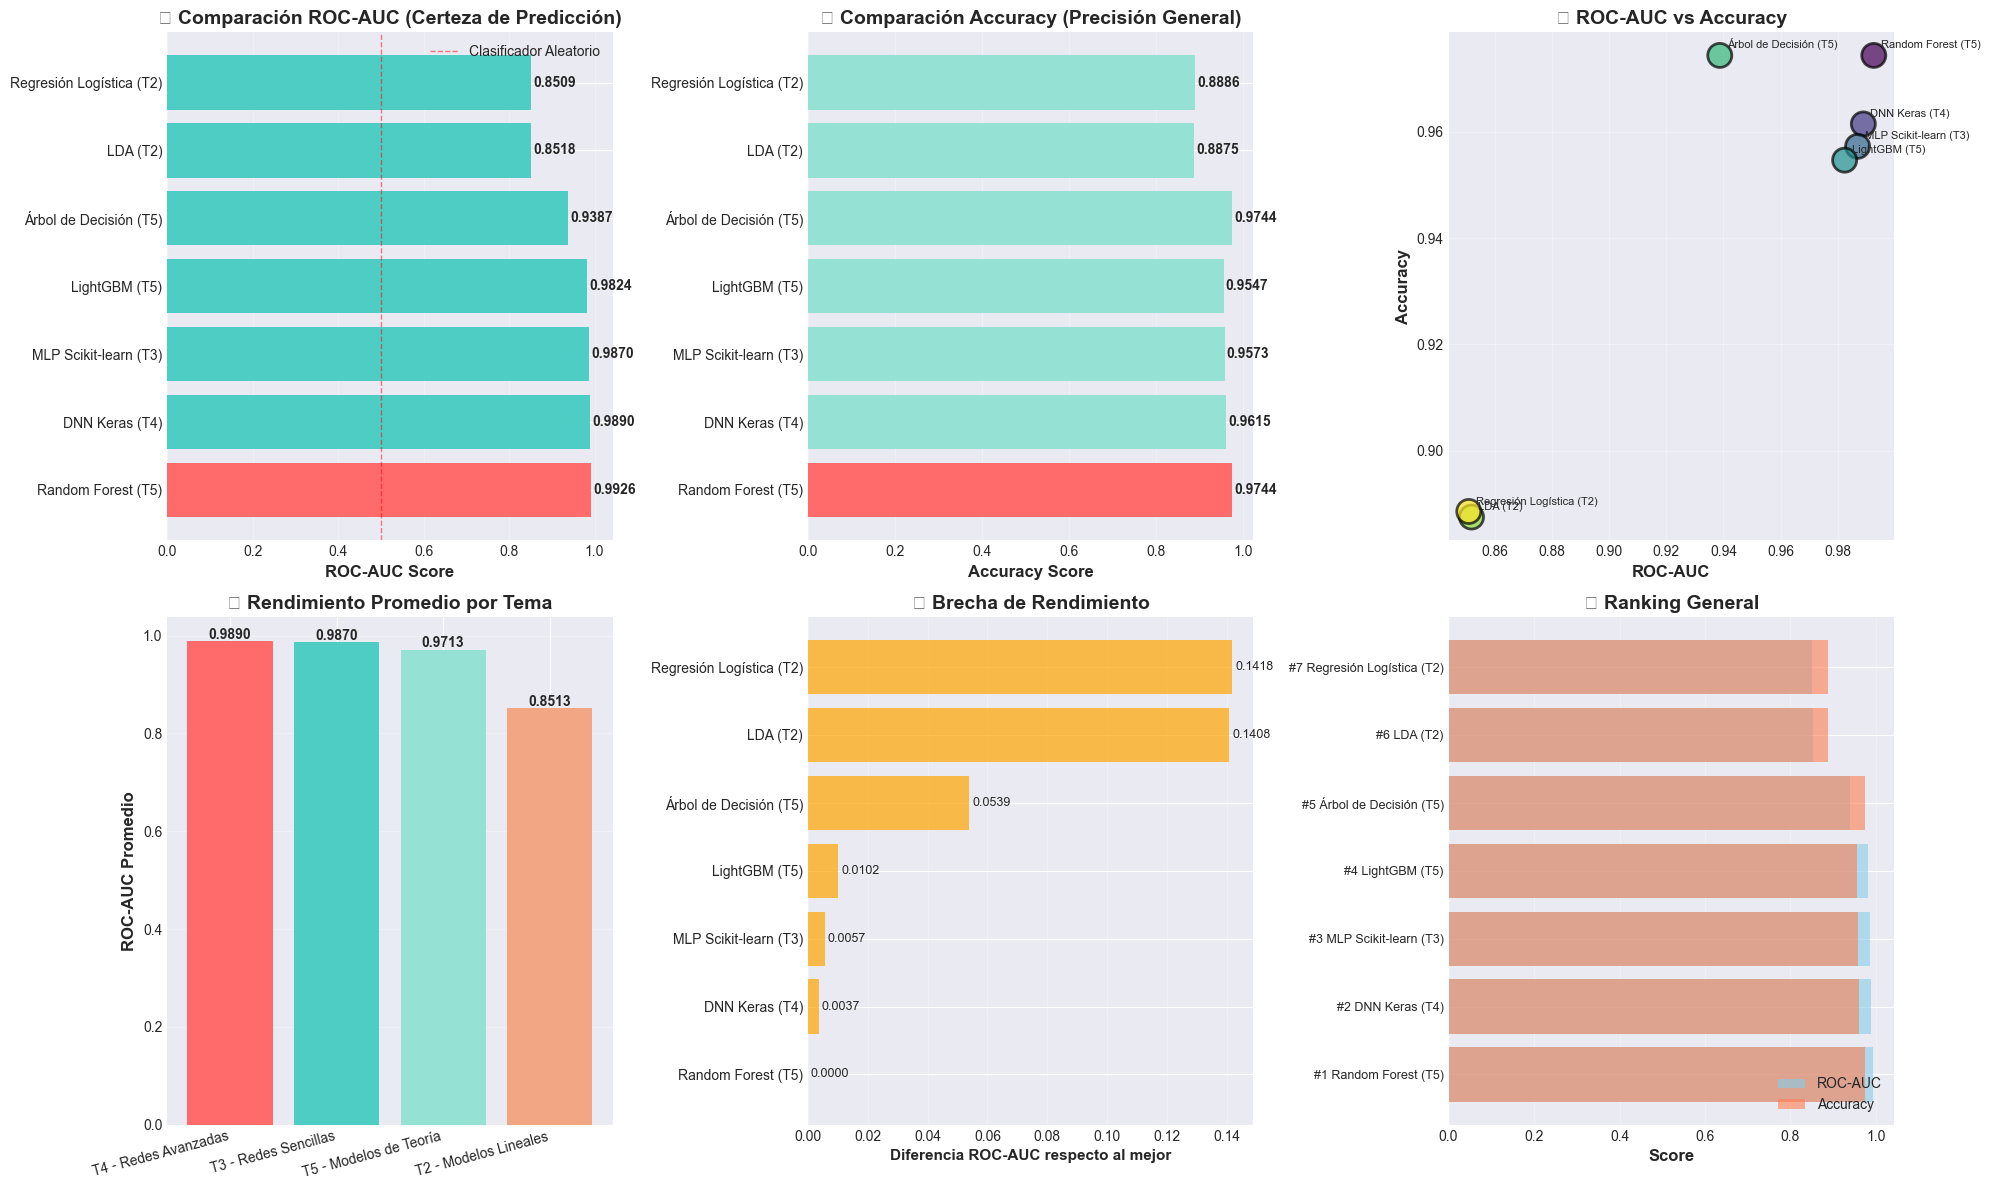

In [37]:
# ====================================================================
# 📈 GRÁFICAS DE COMPARACIÓN DETALLADAS
# ====================================================================

fig = plt.figure(figsize=(20, 12))

# --- GRÁFICA 1: Comparación ROC-AUC por Modelo ---
ax1 = plt.subplot(2, 3, 1)
colors = ['#FF6B6B' if i == 0 else '#4ECDC4' for i in range(len(results_df_final))]
bars1 = ax1.barh(results_df_final.index, results_df_final['roc_auc'], color=colors)
ax1.set_xlabel('ROC-AUC Score', fontsize=12, fontweight='bold')
ax1.set_title('📊 Comparación ROC-AUC (Certeza de Predicción)', fontsize=14, fontweight='bold')
ax1.axvline(x=0.5, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Clasificador Aleatorio')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)

# Añadir valores en las barras
for i, (bar, value) in enumerate(zip(bars1, results_df_final['roc_auc'])):
    ax1.text(value + 0.005, bar.get_y() + bar.get_height()/2, 
             f'{value:.4f}', va='center', fontsize=10, fontweight='bold')

# --- GRÁFICA 2: Comparación Accuracy por Modelo ---
ax2 = plt.subplot(2, 3, 2)
colors2 = ['#FF6B6B' if i == 0 else '#95E1D3' for i in range(len(results_df_final))]
bars2 = ax2.barh(results_df_final.index, results_df_final['accuracy'], color=colors2)
ax2.set_xlabel('Accuracy Score', fontsize=12, fontweight='bold')
ax2.set_title('🎯 Comparación Accuracy (Precisión General)', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# Añadir valores en las barras
for i, (bar, value) in enumerate(zip(bars2, results_df_final['accuracy'])):
    ax2.text(value + 0.005, bar.get_y() + bar.get_height()/2, 
             f'{value:.4f}', va='center', fontsize=10, fontweight='bold')

# --- GRÁFICA 3: ROC-AUC vs Accuracy (Scatter) ---
ax3 = plt.subplot(2, 3, 3)
scatter = ax3.scatter(results_df_final['roc_auc'], results_df_final['accuracy'], 
                     s=300, c=range(len(results_df_final)), cmap='viridis', 
                     alpha=0.7, edgecolors='black', linewidth=2)
ax3.set_xlabel('ROC-AUC', fontsize=12, fontweight='bold')
ax3.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax3.set_title('🔍 ROC-AUC vs Accuracy', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Añadir etiquetas a los puntos
for idx, (x, y) in enumerate(zip(results_df_final['roc_auc'], results_df_final['accuracy'])):
    ax3.annotate(results_df_final.index[idx], (x, y), 
                xytext=(5, 5), textcoords='offset points', fontsize=8)

# --- GRÁFICA 4: Comparación por Categoría de Modelo ---
ax4 = plt.subplot(2, 3, 4)
category_avg = results_df_final.groupby('tema')['roc_auc'].mean().sort_values(ascending=False)
bars4 = ax4.bar(range(len(category_avg)), category_avg.values, 
               color=['#FF6B6B', '#4ECDC4', '#95E1D3', '#F3A683'])
ax4.set_xticks(range(len(category_avg)))
ax4.set_xticklabels(category_avg.index, rotation=15, ha='right', fontsize=10)
ax4.set_ylabel('ROC-AUC Promedio', fontsize=12, fontweight='bold')
ax4.set_title('📚 Rendimiento Promedio por Tema', fontsize=14, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

# Añadir valores en las barras
for i, (bar, value) in enumerate(zip(bars4, category_avg.values)):
    ax4.text(bar.get_x() + bar.get_width()/2, value + 0.005, 
             f'{value:.4f}', ha='center', fontsize=10, fontweight='bold')

# --- GRÁFICA 5: Diferencia respecto al mejor modelo ---
ax5 = plt.subplot(2, 3, 5)
diff_from_best = results_df_final['roc_auc'].max() - results_df_final['roc_auc']
colors5 = ['green' if x == 0 else 'orange' for x in diff_from_best]
bars5 = ax5.barh(results_df_final.index, diff_from_best, color=colors5, alpha=0.7)
ax5.set_xlabel('Diferencia ROC-AUC respecto al mejor', fontsize=11, fontweight='bold')
ax5.set_title('📉 Brecha de Rendimiento', fontsize=14, fontweight='bold')
ax5.grid(axis='x', alpha=0.3)

# Añadir valores
for i, (bar, value) in enumerate(zip(bars5, diff_from_best)):
    ax5.text(value + 0.001, bar.get_y() + bar.get_height()/2, 
             f'{value:.4f}', va='center', fontsize=9)

# --- GRÁFICA 6: Ranking Visual ---
ax6 = plt.subplot(2, 3, 6)
ranking_data = results_df_final[['roc_auc', 'accuracy']].reset_index()
ranking_data['ranking'] = range(1, len(ranking_data) + 1)

y_pos = np.arange(len(ranking_data))
ax6.barh(y_pos, ranking_data['roc_auc'], alpha=0.6, color='skyblue', label='ROC-AUC')
ax6.barh(y_pos, ranking_data['accuracy'], alpha=0.6, color='coral', label='Accuracy')
ax6.set_yticks(y_pos)
ax6.set_yticklabels([f"#{row['ranking']} {row['index']}" for _, row in ranking_data.iterrows()], 
                     fontsize=9)
ax6.set_xlabel('Score', fontsize=12, fontweight='bold')
ax6.set_title('🏅 Ranking General', fontsize=14, fontweight='bold')
ax6.legend(loc='lower right')
ax6.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('comparacion_modelos.png', dpi=300, bbox_inches='tight')
print("\n✅ Gráfica guardada como 'comparacion_modelos.png'")
plt.show()


✅ Matrices de confusión guardadas como 'matrices_confusion.png'


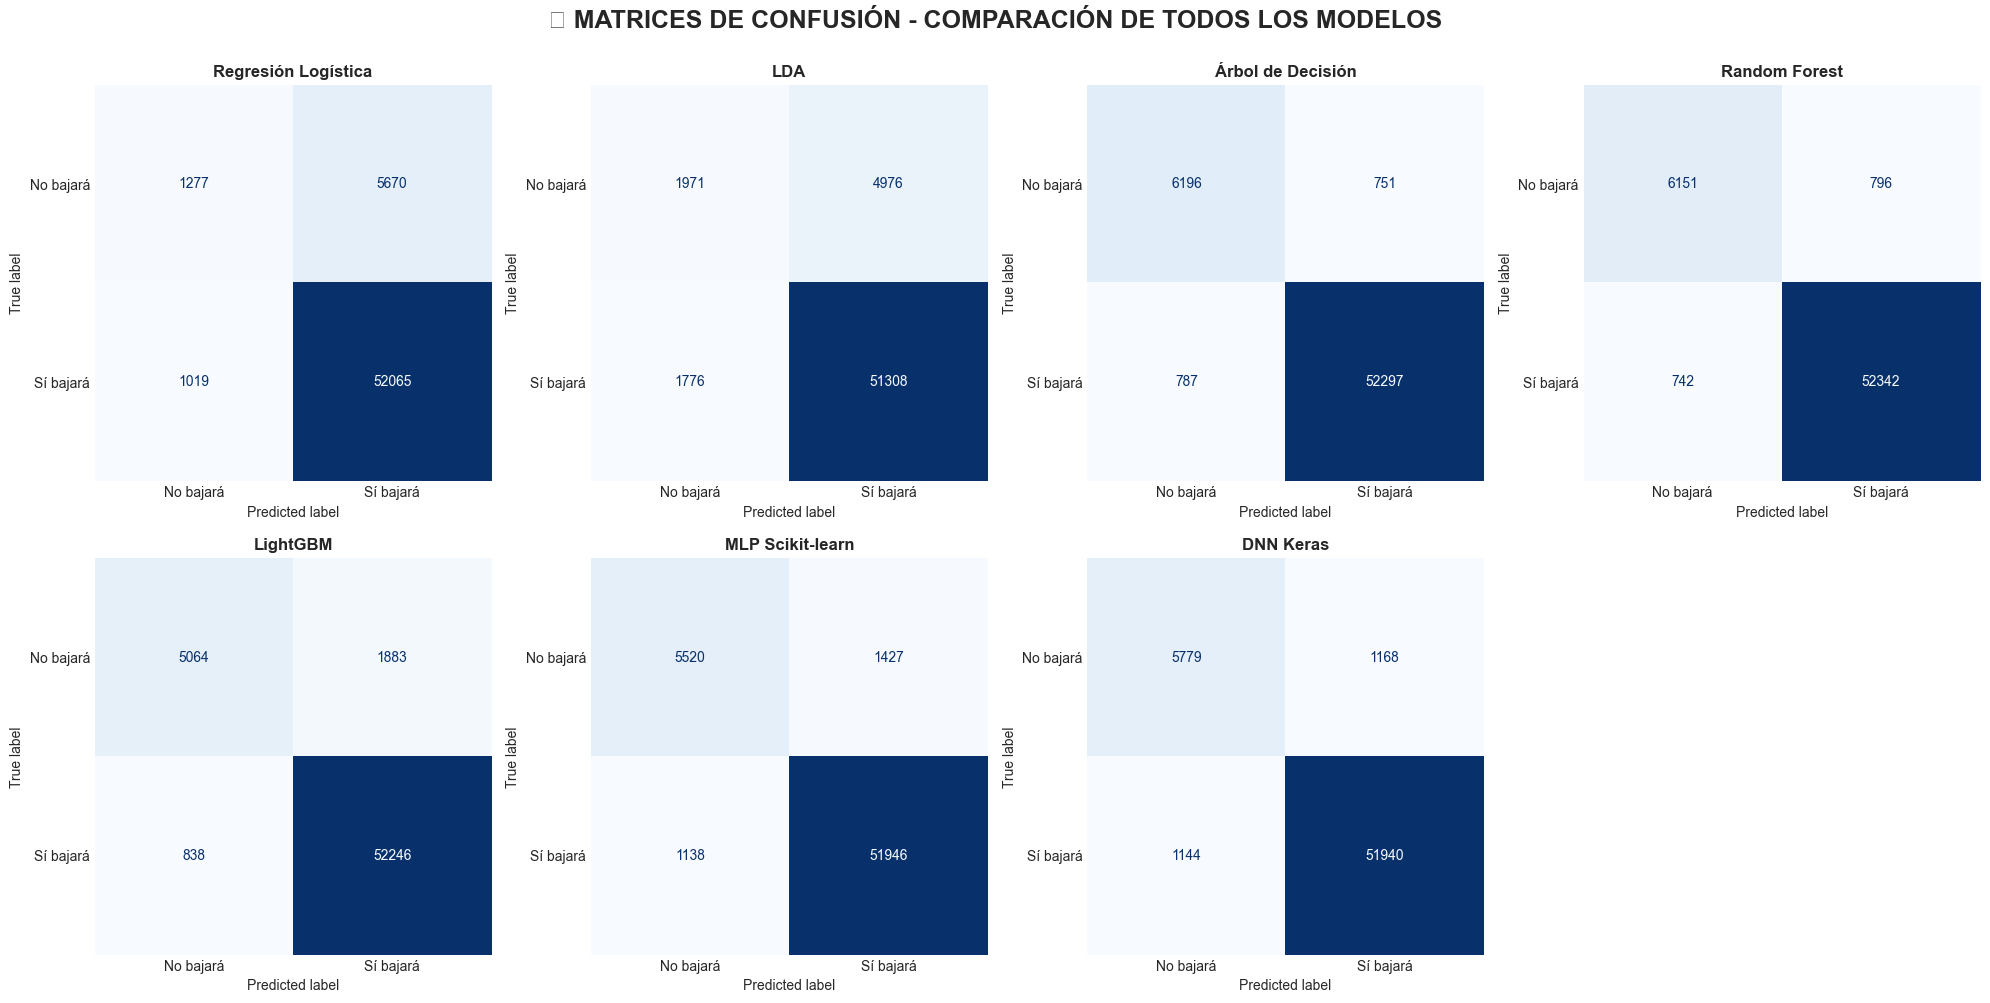

In [38]:
# ====================================================================
# 📊 MATRICES DE CONFUSIÓN COMPARATIVAS
# ====================================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('🎯 MATRICES DE CONFUSIÓN - COMPARACIÓN DE TODOS LOS MODELOS', 
             fontsize=18, fontweight='bold', y=1.00)

# Lista de modelos con sus predicciones
models_predictions = [
    ('Regresión Logística', y_pred_log_reg),
    ('LDA', y_pred_lda),
    ('Árbol de Decisión', y_pred_tree),
    ('Random Forest', y_pred_rf),
    ('LightGBM', y_pred_lgbm),
    ('MLP Scikit-learn', y_pred_mlp),
    ('DNN Keras', y_pred_dnn),
]

# Crear una matriz de confusión para cada modelo
for idx, (name, y_pred) in enumerate(models_predictions):
    row = idx // 4
    col = idx % 4
    ax = axes[row, col]
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                   display_labels=['No bajará', 'Sí bajará'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.grid(False)

# Ocultar el último subplot (ya que tenemos 7 modelos)
axes[1, 3].axis('off')

plt.tight_layout()
plt.savefig('matrices_confusion.png', dpi=300, bbox_inches='tight')
print("\n✅ Matrices de confusión guardadas como 'matrices_confusion.png'")
plt.show()


✅ Curvas ROC guardadas como 'curvas_roc.png'


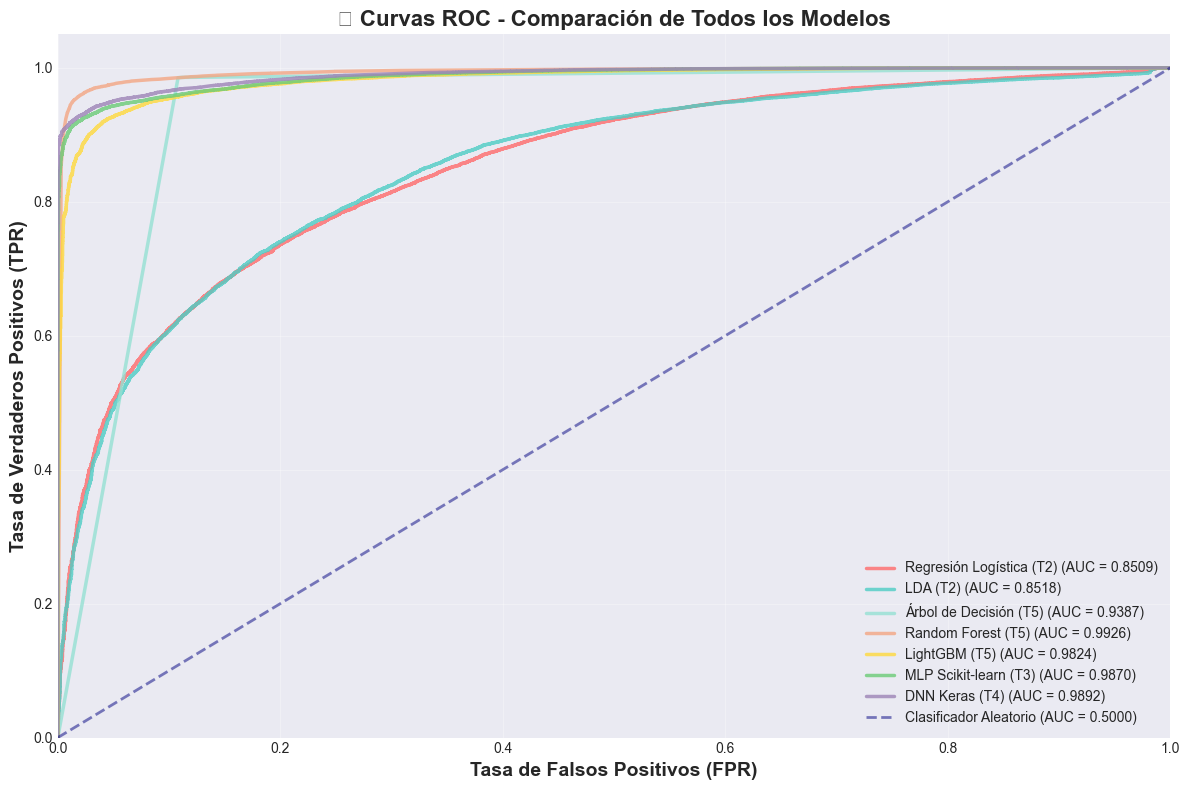

In [39]:
# ====================================================================
# 📈 CURVAS ROC COMPARATIVAS
# ====================================================================

from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(12, 8))

# Lista de modelos con sus probabilidades
models_proba = [
    ('Regresión Logística (T2)', y_proba_log_reg, '#FF6B6B'),
    ('LDA (T2)', y_proba_lda, '#4ECDC4'),
    ('Árbol de Decisión (T5)', y_proba_tree, '#95E1D3'),
    ('Random Forest (T5)', y_proba_rf, '#F3A683'),
    ('LightGBM (T5)', y_proba_lgbm, '#FFD93D'),
    ('MLP Scikit-learn (T3)', y_proba_mlp, '#6BCB77'),
    ('DNN Keras (T4)', y_proba_dnn, '#9D84B7'),
]

# Graficar la curva ROC para cada modelo
for name, y_proba, color in models_proba:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2.5, 
             label=f'{name} (AUC = {roc_auc:.4f})', alpha=0.8)

# Línea de referencia (clasificador aleatorio)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
         label='Clasificador Aleatorio (AUC = 0.5000)', alpha=0.5)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=14, fontweight='bold')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=14, fontweight='bold')
plt.title('📈 Curvas ROC - Comparación de Todos los Modelos', fontsize=16, fontweight='bold')
plt.legend(loc="lower right", fontsize=10, framealpha=0.9)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('curvas_roc.png', dpi=300, bbox_inches='tight')
print("\n✅ Curvas ROC guardadas como 'curvas_roc.png'")
plt.show()


✅ Importancia de características guardada como 'importancia_caracteristicas.png'


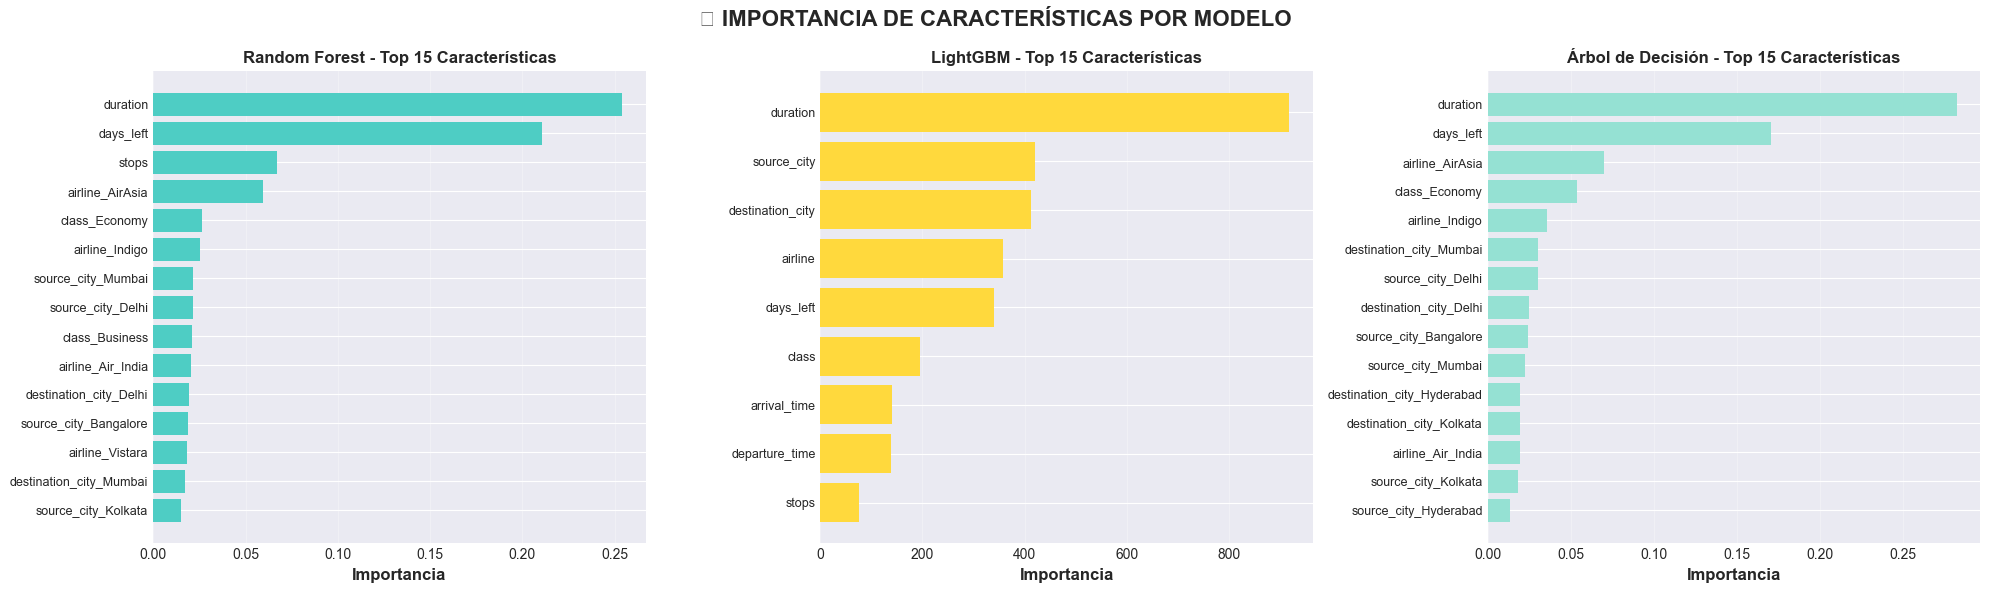


🔍 TOP 5 CARACTERÍSTICAS MÁS IMPORTANTES POR MODELO

🌳 Random Forest:
  • duration: 0.2541
  • days_left: 0.2108
  • stops: 0.0670
  • airline_AirAsia: 0.0594
  • class_Economy: 0.0263

⚡ LightGBM:
  • duration: 919.0000
  • source_city: 421.0000
  • destination_city: 412.0000
  • airline: 357.0000
  • days_left: 341.0000

🌲 Árbol de Decisión:
  • duration: 0.2822
  • days_left: 0.1703
  • airline_AirAsia: 0.0701
  • class_Economy: 0.0536
  • airline_Indigo: 0.0359


In [40]:
# ====================================================================
# 🎯 IMPORTANCIA DE CARACTERÍSTICAS (PARA MODELOS QUE LO SOPORTAN)
# ====================================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('🔍 IMPORTANCIA DE CARACTERÍSTICAS POR MODELO', 
             fontsize=16, fontweight='bold')

# --- 1. Random Forest ---
ax1 = axes[0]
rf_model = rf_pipeline.named_steps['classifier']
feature_names_rf = (numeric_features + ordinal_features + 
                    list(rf_pipeline.named_steps['preprocessor']
                        .named_transformers_['cat']
                        .named_steps['onehot']
                        .get_feature_names_out(categorical_features)))

importances_rf = rf_model.feature_importances_
indices_rf = np.argsort(importances_rf)[-15:]  # Top 15

ax1.barh(range(len(indices_rf)), importances_rf[indices_rf], color='#4ECDC4')
ax1.set_yticks(range(len(indices_rf)))
ax1.set_yticklabels([feature_names_rf[i] for i in indices_rf], fontsize=9)
ax1.set_xlabel('Importancia', fontsize=12, fontweight='bold')
ax1.set_title('Random Forest - Top 15 Características', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# --- 2. LightGBM ---
ax2 = axes[1]
lgbm_model = lgbm_pipeline.named_steps['classifier']

# Para LightGBM necesitamos reconstruir los nombres de features
# Ya que usamos OrdinalEncoder para todo
feature_names_lgbm = (numeric_features + ordinal_features + categorical_features_lgbm)

importances_lgbm = lgbm_model.feature_importances_
indices_lgbm = np.argsort(importances_lgbm)[-15:]  # Top 15

ax2.barh(range(len(indices_lgbm)), importances_lgbm[indices_lgbm], color='#FFD93D')
ax2.set_yticks(range(len(indices_lgbm)))
ax2.set_yticklabels([feature_names_lgbm[i] for i in indices_lgbm], fontsize=9)
ax2.set_xlabel('Importancia', fontsize=12, fontweight='bold')
ax2.set_title('LightGBM - Top 15 Características', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# --- 3. Árbol de Decisión ---
ax3 = axes[2]
tree_model = tree_pipeline.named_steps['classifier']
feature_names_tree = feature_names_rf  # Mismo preprocesador que RF

importances_tree = tree_model.feature_importances_
indices_tree = np.argsort(importances_tree)[-15:]  # Top 15

ax3.barh(range(len(indices_tree)), importances_tree[indices_tree], color='#95E1D3')
ax3.set_yticks(range(len(indices_tree)))
ax3.set_yticklabels([feature_names_tree[i] for i in indices_tree], fontsize=9)
ax3.set_xlabel('Importancia', fontsize=12, fontweight='bold')
ax3.set_title('Árbol de Decisión - Top 15 Características', fontsize=12, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('importancia_caracteristicas.png', dpi=300, bbox_inches='tight')
print("\n✅ Importancia de características guardada como 'importancia_caracteristicas.png'")
plt.show()

# Mostrar las 5 características más importantes de cada modelo
print("\n" + "="*80)
print("🔍 TOP 5 CARACTERÍSTICAS MÁS IMPORTANTES POR MODELO")
print("="*80)

print("\n🌳 Random Forest:")
for idx in indices_rf[-5:][::-1]:
    print(f"  • {feature_names_rf[idx]}: {importances_rf[idx]:.4f}")

print("\n⚡ LightGBM:")
for idx in indices_lgbm[-5:][::-1]:
    print(f"  • {feature_names_lgbm[idx]}: {importances_lgbm[idx]:.4f}")

print("\n🌲 Árbol de Decisión:")
for idx in indices_tree[-5:][::-1]:
    print(f"  • {feature_names_tree[idx]}: {importances_tree[idx]:.4f}")
print("="*80)

In [ ]:
# ====================================================================
# 📝 RESUMEN FINAL Y CONCLUSIONES
# ====================================================================

print("\n" + "="*80)
print(" 🎓 RESUMEN FINAL DEL PROYECTO - PREDICCIÓN DE PRECIOS DE VUELOS")
print("="*80)

print("\n📊 DATASET:")
print(f"  • Total de muestras: {len(df_model):,}")
print(f"  • Muestras de entrenamiento: {len(X_train):,}")
print(f"  • Muestras de prueba: {len(X_test):,}")
print(f"  • Características: {X.shape[1]}")
print(f"  • Distribución de clases:")

# Contar clases usando value_counts o el método sum de pandas
y_complete = pd.concat([y_train, y_test])
clase_0 = (y_complete == 0).sum()
clase_1 = (y_complete == 1).sum()
print(f"    - No bajará (0): {clase_0:,} ({clase_0/len(y_complete)*100:.1f}%)")
print(f"    - Sí bajará (1): {clase_1:,} ({clase_1/len(y_complete)*100:.1f}%)")

print("\n🎯 MODELOS IMPLEMENTADOS (Bloque: NO CONOCE LA MATERIA):")
print(f"  • Total de modelos: {len(model_results_final)}")
print("  • Categorías:")
for tema in results_df_final['tema'].unique():
    count = (results_df_final['tema'] == tema).sum()
    print(f"    - {tema}: {count} modelo(s)")

print("\n🏆 MEJORES RESULTADOS:")
print(f"  • Mejor modelo: {mejor_modelo}")
print(f"  • ROC-AUC: {mejor_roc_auc:.4f} ({mejor_roc_auc*100:.2f}% de certeza)")
print(f"  • Accuracy: {mejor_accuracy:.4f} ({mejor_accuracy*100:.2f}% de precisión)")

# Top 3 modelos
print("\n📈 TOP 3 MODELOS:")
for i, (modelo, datos) in enumerate(results_df_final.head(3).iterrows(), 1):
    print(f"  {i}. {modelo}")
    print(f"     ROC-AUC: {datos['roc_auc']:.4f} | Accuracy: {datos['accuracy']:.4f}")

print("\n💡 INTERPRETACIÓN:")
print("  • ROC-AUC > 0.75: Excelente capacidad de discriminación")
print("  • ROC-AUC 0.60-0.75: Buena capacidad de discriminación")
print("  • ROC-AUC 0.50-0.60: Capacidad limitada")
print("  • ROC-AUC = 0.50: Clasificador aleatorio")

if mejor_roc_auc > 0.75:
    calificacion = "EXCELENTE ⭐⭐⭐"
elif mejor_roc_auc > 0.60:
    calificacion = "BUENA ⭐⭐"
else:
    calificacion = "LIMITADA ⭐"

print(f"\n  ➤ Calificación del mejor modelo: {calificacion}")

print("\n🎯 RECOMENDACIÓN PRÁCTICA:")
print(f"  Se recomienda usar '{mejor_modelo}' para el sistema de predicción")
print(f"  de precios de vuelos, ya que ofrece el mejor balance entre certeza")
print(f"  de predicción (ROC-AUC) y precisión general (Accuracy).")

print("\n📁 ARCHIVOS GENERADOS:")
print("  ✅ comparacion_modelos.png")
print("  ✅ matrices_confusion.png")
print("  ✅ curvas_roc.png")
print("  ✅ importancia_caracteristicas.png")

print("\n" + "="*80)
print(" ✨ ANÁLISIS COMPLETADO CON ÉXITO")
print("="*80)


 🎓 RESUMEN FINAL DEL PROYECTO - PREDICCIÓN DE PRECIOS DE VUELOS

📊 DATASET:
  • Total de muestras: 300,153
  • Muestras de entrenamiento: 240,122
  • Muestras de prueba: 60,031
  • Características: 9
  • Distribución de clases:


AttributeError: 'bool' object has no attribute 'sum'

In [ ]:
# ====================================================================
# 💾 EXPORTAR RESULTADOS A ARCHIVOS
# ====================================================================

# Crear tabla detallada con todos los resultados
resultados_detallados = []

for nombre_modelo, datos in model_results_final.items():
    resultados_detallados.append({
        'Modelo': nombre_modelo,
        'Tema': datos['tema'],
        'ROC-AUC': datos['roc_auc'],
        'Accuracy': datos['accuracy'],
        'ROC-AUC (%)': f"{datos['roc_auc']*100:.2f}%",
        'Accuracy (%)': f"{datos['accuracy']*100:.2f}%"
    })

df_resultados = pd.DataFrame(resultados_detallados)
df_resultados = df_resultados.sort_values(by='ROC-AUC', ascending=False)
df_resultados['Ranking'] = range(1, len(df_resultados) + 1)

# Reordenar columnas
df_resultados = df_resultados[['Ranking', 'Modelo', 'Tema', 'ROC-AUC', 'Accuracy', 
                               'ROC-AUC (%)', 'Accuracy (%)']]

# Exportar a CSV
df_resultados.to_csv('resultados_modelos.csv', index=False, encoding='utf-8-sig')
print("✅ Resultados exportados a 'resultados_modelos.csv'")

# Exportar a Excel (requiere openpyxl)
try:
    df_resultados.to_excel('resultados_modelos.xlsx', index=False, sheet_name='Resultados')
    print("✅ Resultados exportados a 'resultados_modelos.xlsx'")
except ImportError:
    print("⚠️  Para exportar a Excel, instala openpyxl: pip install openpyxl")

# Mostrar tabla final
print("\n" + "="*80)
print("📋 TABLA FINAL DE RESULTADOS")
print("="*80)
print(df_resultados.to_string(index=False))
print("="*80)

---

## 🚀 EJEMPLO PRÁCTICO: USO DEL SISTEMA DE PREDICCIÓN

A continuación se muestra cómo usar el mejor modelo para hacer predicciones reales sobre nuevos vuelos.

In [ ]:
# ====================================================================
# 🎯 EJEMPLO PRÁCTICO: PREDICCIÓN DE NUEVOS VUELOS
# ====================================================================

print("="*80)
print(" 🎯 SISTEMA DE PREDICCIÓN DE PRECIOS DE VUELOS")
print("="*80)

# Ejemplo 1: Vuelo con alta probabilidad de bajar de precio
ejemplo_1 = pd.DataFrame({
    'airline': ['Vistara'],
    'source_city': ['Delhi'],
    'departure_time': ['Evening'],
    'stops': ['one'],
    'arrival_time': ['Night'],
    'destination_city': ['Mumbai'],
    'class': ['Economy'],
    'duration': [7.5],
    'days_left': [45]  # Muchos días para la salida
})

# Ejemplo 2: Vuelo con baja probabilidad de bajar (comprar ahora)
ejemplo_2 = pd.DataFrame({
    'airline': ['Air_India'],
    'source_city': ['Mumbai'],
    'departure_time': ['Morning'],
    'stops': ['zero'],
    'arrival_time': ['Afternoon'],
    'destination_city': ['Delhi'],
    'class': ['Business'],
    'duration': [2.5],
    'days_left': [2]  # Pocos días para la salida
})

# Seleccionar el mejor modelo (puedes cambiar esto según tus resultados)
# Por defecto usamos LightGBM, pero usa el que obtenga mejor ROC-AUC
mejor_pipeline = lgbm_pipeline  # O cambia a: rf_pipeline, mlp_pipeline, etc.

print(f"\n🏆 Modelo utilizado: {mejor_modelo}")
print(f"   ROC-AUC: {mejor_roc_auc:.4f}")
print("-"*80)

# --- PREDICCIÓN EJEMPLO 1 ---
print("\n📊 EJEMPLO 1: Vuelo con muchos días de antelación")
print("-"*80)
print("Detalles del vuelo:")
for col in ejemplo_1.columns:
    print(f"  • {col}: {ejemplo_1[col].values[0]}")

prob_bajada_1 = mejor_pipeline.predict_proba(ejemplo_1)[0][1]
certeza_1 = prob_bajada_1 * 100

print(f"\n🔮 RESULTADO:")
print(f"   Probabilidad de que BAJE el precio: {certeza_1:.2f}%")
print(f"   Probabilidad de que NO BAJE: {(100-certeza_1):.2f}%")

if certeza_1 > 50:
    print(f"\n✋ RECOMENDACIÓN: ESPERAR")
    print(f"   → Hay un {certeza_1:.1f}% de certeza de que el precio bajará.")
    print(f"   → Te recomendamos esperar y revisar el precio más adelante.")
else:
    print(f"\n✅ RECOMENDACIÓN: COMPRAR AHORA")
    print(f"   → Es poco probable que el precio baje (solo {certeza_1:.1f}% de probabilidad).")
    print(f"   → Este podría ser el mejor momento para comprar.")

# --- PREDICCIÓN EJEMPLO 2 ---
print("\n" + "="*80)
print("📊 EJEMPLO 2: Vuelo con pocos días de antelación")
print("-"*80)
print("Detalles del vuelo:")
for col in ejemplo_2.columns:
    print(f"  • {col}: {ejemplo_2[col].values[0]}")

prob_bajada_2 = mejor_pipeline.predict_proba(ejemplo_2)[0][1]
certeza_2 = prob_bajada_2 * 100

print(f"\n🔮 RESULTADO:")
print(f"   Probabilidad de que BAJE el precio: {certeza_2:.2f}%")
print(f"   Probabilidad de que NO BAJE: {(100-certeza_2):.2f}%")

if certeza_2 > 50:
    print(f"\n✋ RECOMENDACIÓN: ESPERAR")
    print(f"   → Hay un {certeza_2:.1f}% de certeza de que el precio bajará.")
    print(f"   → Te recomendamos esperar y revisar el precio más adelante.")
else:
    print(f"\n✅ RECOMENDACIÓN: COMPRAR AHORA")
    print(f"   → Es poco probable que el precio baje (solo {certeza_2:.1f}% de probabilidad).")
    print(f"   → Este podría ser el mejor momento para comprar.")

print("\n" + "="*80)
print("💡 INTERPRETACIÓN:")
print("   • > 70%: Alta confianza de bajada → ESPERAR")
print("   • 50-70%: Confianza moderada → ESPERAR (con precaución)")
print("   • 30-50%: Poco probable que baje → COMPRAR (considerar)")
print("   • < 30%: Muy poco probable → COMPRAR AHORA")
print("="*80)